In [15]:
# Notebook setup

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import os

TARGET_CRS = "EPSG:5070"
RENDER_FRIENDLY_CRS = "EPSG:4326"

os.chdir(Path(
    r"C:\Projects\geospatial_usa"
))

In [18]:
folder = Path("./census")

IllinoisCensus = {}

for file in folder.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        IllinoisCensus[file.name] = pd.read_csv(file)

In [53]:
# Load in datasets

ILTractsWithoutPlaces = gpd.read_file("./census/WithNoPlace_ILPlacesTracts2020_WithCensusData.geojson").to_crs(TARGET_CRS)
ILCounties = gpd.read_file("./maps/raw/counties_by_state/IL.geojson").to_crs(TARGET_CRS)
ILTracts2020 = gpd.read_file('./maps/raw/historical_census_tracts_by_state/tracts_2022/Illinois_tl_2022_17_tract/tl_2022_17_tract.shp').to_crs(TARGET_CRS)
ILPlaces = gpd.read_file("./maps/raw/IL/tl_2025_17_place/tl_2025_17_place.shp").to_crs(TARGET_CRS)
CollarArea = gpd.read_file("./maps/raw/IL/IL_ChicagoCollarCountiesArea.geojson").to_crs(TARGET_CRS)

ILTracts2020["GEOID"] = ILTracts2020["GEOID"].astype(str)
ILPlaces["GEOID"] = ILPlaces["GEOID"].astype(str)

In [54]:
# Method: Classify un-placed tracts into counties
def classifySmallIntoLargerGeoDatabase(a, b, c):

    smaller = a.copy()
    larger = b.copy()
    
    overlaps = gpd.overlay(
        smaller,
        larger,
        how="intersection",
    )

    # Calculate overlap area
    overlaps["overlap_area"] = overlaps.geometry.area

    # Keep the community area with the largest overlap per tract
    largest_overlap = (
        overlaps
        .sort_values("overlap_area", ascending=False)
        .drop_duplicates(subset="GEOID")
    )

    # Attach the classification to the original tract polygons
    return a.merge(
        largest_overlap[c],
        on="GEOID",
        how="left",
    )

In [55]:
classified_tracts_with_best_overlapped_places = classifySmallIntoLargerGeoDatabase(
    a=ILTracts2020,  
    b=ILPlaces[
        ["GEOID", "NAME", "geometry"]
    ].rename(
            columns={
                "GEOID": "PLACE_GEOID",
                "NAME": "PLACE_NAME",
            }
        ),
    c=["GEOID", "PLACE_GEOID", "PLACE_NAME"]
)

c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 6098 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [56]:
classified_unplaced_tracts_into_counties = classifySmallIntoLargerGeoDatabase(
    a=ILTractsWithoutPlaces,  
    b=ILCounties[
        ["FIPS", "NAME", "geometry"]
    ].rename(
            columns={
                "FIPS": "COUNTY_FIPS",
                "NAME": "COUNTY_NAME",
            }
        ),
    c=["GEOID", "COUNTY_FIPS", "COUNTY_NAME"]
)

In [57]:
classified_unplaced_tracts_into_counties[['GEOID', 'COUNTY_NAME']]

,GEOID,COUNTY_NAME
0,17089854505,KANE
1,17077010601,JACKSON
2,17143003700,PEORIA
3,17167003601,SANGAMON
4,17031990000,NaN
5,17195001800,WHITESIDE
6,17087980000,JOHNSON
7,17097990000,NaN
8,17197883808,WILL


In [64]:
classified_unplaced_tracts_into_counties = classified_unplaced_tracts_into_counties[(
    (~classified_unplaced_tracts_into_counties['COUNTY_NAME'].isna())
)]

In [66]:
classified_unplaced_tracts_into_counties["PLACE_NAME"] = (
    "Uninc. "
    + classified_unplaced_tracts_into_counties["COUNTY_NAME"].astype(str) + " County"
)

classified_unplaced_tracts_into_counties["PLACE_GEOID"] = (
    "UNC_"
    + classified_unplaced_tracts_into_counties["COUNTY_NAME"].astype(str)
    + "_"
    + classified_unplaced_tracts_into_counties.index.astype(str)
)

In [58]:
def ZoomToTheExtentOf(ax, geoDataFrame):
    minx, miny, maxx, maxy = geoDataFrame.total_bounds

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    return ax

In [59]:
classified_unplaced_tracts_into_counties[(
    classified_unplaced_tracts_into_counties['COUNTY_NAME'].isna()
)]

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,...,B01001_043E,B01001_044E,B01001_045E,B01001_046E,B01001_047E,B01001_048E,B01001_049E,geometry,COUNTY_FIPS,COUNTY_NAME
4,17,031,990000,17031990000,9900,Census Tract 9900,G5020,S,0,1717072182,...,0,0,0,0,0,0,0,"POLYGON ((677048.435 2157487.53, 678665.642 21...",NaN,NaN
7,17,097,990000,17097990000,9900,Census Tract 9900,G5020,S,0,2298779958,...,0,0,0,0,0,0,0,"POLYGON ((669131.799 2173216.226, 669157.981 2...",NaN,NaN


In [71]:
classified_tracts_with_best_overlapped_places = classified_tracts_with_best_overlapped_places[(
    (~classified_tracts_with_best_overlapped_places['PLACE_NAME'].isna())
)]

In [72]:
classified_tracts_with_best_overlapped_places_withUnplaced = gpd.GeoDataFrame(
    pd.concat([
        classified_tracts_with_best_overlapped_places,
        classified_unplaced_tracts_into_counties
    ]),
    crs=classified_tracts_with_best_overlapped_places.crs
)

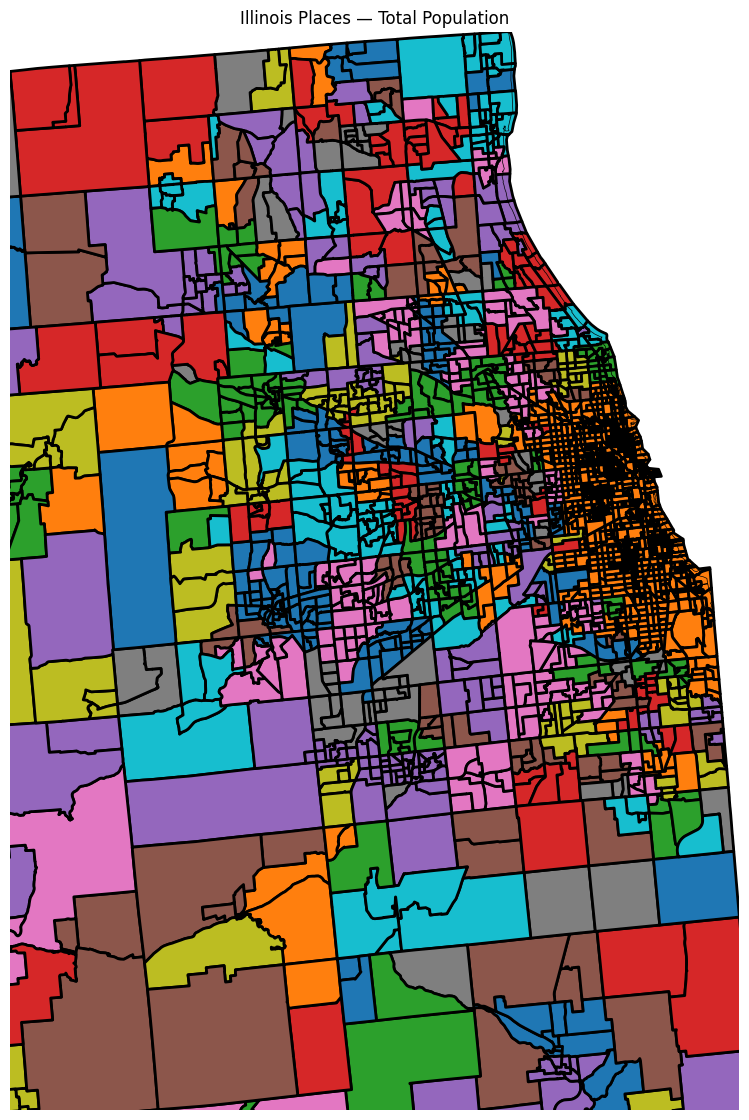

In [77]:
fig, ax = plt.subplots(figsize=(14, 14))

classified_tracts_with_best_overlapped_places_withUnplaced.plot(
    ax=ax,
    column="PLACE_NAME",
    categorical=True,
    legend=False,
    edgecolor="#000000",
    linewidth=2,
)

ILCounties.plot(
    ax=ax,
    edgecolor="#000000",
    color="#ffffff00",
    linewidth=0.5,
)


ZoomToTheExtentOf(ax, CollarArea)

ax.set_axis_off()
ax.set_title("Illinois Places — Total Population")
plt.show()


In [74]:
classified_tracts_with_best_overlapped_places_withUnplaced.to_file("ILPlacesCensusTracts2020.geojson")